## CNN Model with Transfer Learning
The advanced Convolution Neural Network is a combination of two models.

* The 1st model is a species classifier named "animal classifier model", which was trained on 10,000 animal faces datasets consisting a set of species such that the model learned to identify e.g. cat from dog, and dog from others. The labels of the animal dataset were respectively: cat, dog, and wild.
  * This model consists of five 2D Convolutional layers activated with ReLU functions, with each layer followed by a maximum pooling layer to avoid overfitting.
  * Once the facial segmentation is finished, this feature map outputs are fed into a flatten layer that is then connected to two fully connected layers for multi-class classification. Again, softmax function is employed as the activation function.
* The 2nd model is an emotional classifier where the emotion classification boundary would depend on the type of species, namely, the output of species classifier. It is evident that in this case, transfer learning where a pre-trained model should be embedded into this emotional model for optimal performance.
  * This model serves as the last output layers of the species classifier such that the output layers of species classifier is replaced with the 2nd model flattening layers and dense layers. These layers are for multi-emotion classes categorizing. These Layers are activated with ReLU function to learn the facial expression and softmax function to compute the probability of each class among multiple emotion classes.

## CNN Model with Transfer Learning test achievement
|           | Precision | Recall | F1-Score | Support |
|-----------|-----------|--------|----------|---------|
| Happy     | 0.60      | 0.50   | 0.55     | 52      |
| Sad       | 0.59      | 0.67   | 0.63     | 55      |
| Angry     | 0.68      | 0.70   | 0.69     | 43      |
|   other   | 0.63      | 0.53   | 0.58     | 49
| Accuracy  |           |        | 0.62     | 150     |
| Macro avg | 0.62      | 0.62   | 0.62     | 150     |
| Weighted avg | 0.62   | 0.62   | 0.62     | 150     |

### Transfer Learning Briefing
Using data from a different task.

**Concept of Transfer Learning:**
* Transfer learning is a technique where you use data and learned features from one task to improve performance on a different but related task.
* Especially useful when you have limited data for your target task.

**Process of Transfer Learning:**
* Start by training a large neural network on a big dataset (e.g., 1 million images of various classes).
* Transfer the learned features (weights and biases) of the initial layers to a new neural network, but replace the output layer to suit your specific task (e.g., recognizing digits 0-9).

**Two options for further training:**
* Train only the new output layer's parameters (useful for very small datasets).
* Train all parameters in the network, using the transferred weights as initial values (better for slightly larger datasets).

**Benefits of Transfer Learning:**
* Allows for training on smaller datasets by utilizing pre-learned features.
* Effective in leveraging large pre-trained models available online, saving time and computational resources.
* Particularly beneficial when pre-training and fine-tuning tasks have similar types of input data (like images or audio).

**Intuition Behind Effectiveness:**
* Early layers of neural networks often learn to detect general features (like edges, corners, or basic shapes in images) that are useful across a wide range of tasks.
* These generalized features can be effectively transferred to a new task.

In [65]:
# from google.colab import drive
# drive.mount('/content/drive')

In [66]:
import os
import cv2
import numpy as np
from sklearn.model_selection import train_test_split
import tensorflow as tf
from keras.utils import to_categorical
from keras.models import Sequential, load_model, Model
from keras.layers import Dense, Conv2D, MaxPooling2D, Flatten, Dropout, Input
from IPython.display import display, Image
from keras.layers import BatchNormalization
from keras.callbacks import EarlyStopping
# from keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [67]:
# Define the path to the dataset folders
happy_folder = "/content/drive/MyDrive/Pet_emothion_Recognition-main/pets_facial_expression_dataset/happy"
sad_folder = "/content/drive/MyDrive/Pet_emothion_Recognition-main/pets_facial_expression_dataset/Sad"
angry_folder = "/content/drive/MyDrive/Pet_emothion_Recognition-main/pets_facial_expression_dataset/Angry"
orthr_folder="/content/drive/MyDrive/Pet_emothion_Recognition-main/pets_facial_expression_dataset/Other"
# Function to load and preprocess images
def load_images_from_folder(folder):
    images = []
    for filename in os.listdir(folder):
        img = cv2.imread(os.path.join(folder, filename))
        if img is not None:
            # img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
            img = cv2.resize(img, (128, 128))  # Resize to a fixed size for the model
            images.append(img)
    return images

# Load images and labels for each emotion
happy_images = load_images_from_folder(happy_folder)
sad_images = load_images_from_folder(sad_folder)
angry_images = load_images_from_folder(angry_folder)
other_images = load_images_from_folder(orthr_folder) # Renamed to other_images for clarity

# Create labels for each emotion category
happy_labels = [0] * len(happy_images)
sad_labels = [1] * len(sad_images)
angry_labels = [2] * len(angry_images)
other_labels = [3] * len(other_images) # New variable for 'Other' labels

# Concatenate images and labels
X = np.array(happy_images + sad_images + angry_images + other_images)
y = np.array(happy_labels + sad_labels + angry_labels + other_labels)

# Normalize pixel values to range [0, 1]
X = X.astype('float32') / 255.0

# One-hot encode the labels
# The number of classes should be 4 (happy, sad, angry, other), not 3
y = to_categorical(y, num_classes=4)

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#### Load the dataset  (Optional if integrate another model)

In [68]:
# train_gen=ImageDataGenerator(rescale=1./255)
# train_data=train_gen.flow_from_directory('pets_facial_expression_dataset/master/train',target_size=(128,128),batch_size=32,class_mode='categorical',shuffle=True)
# val_gen=ImageDataGenerator(rescale=1./255)
# val_data=val_gen.flow_from_directory('pets_facial_expression_dataset/master/valid',target_size=(128,128),batch_size=1,class_mode='categorical',shuffle=False)
# test_gen=ImageDataGenerator(rescale=1./255)
# test_data=test_gen.flow_from_directory('pets_facial_expression_dataset/master/test',target_size=(128,128),batch_size=1,class_mode='categorical',shuffle=False)

#### Load the pre-trained model (Optional if integrate another model)

In [69]:
from tensorflow.keras.models import load_model, Model
from tensorflow.keras.layers import Input, Dense, Dropout
import numpy as np

# Load the model
pretrained_animal_classifier = load_model(
    "/content/drive/MyDrive/Pet_emothion_Recognition-main/animal_classifier_model.h5"
)

# ---- Determine the expected input shape ----
input_shape = None

# Try to get input_shape from model or first layer
if hasattr(pretrained_animal_classifier, 'input_shape') and pretrained_animal_classifier.input_shape:
    input_shape = pretrained_animal_classifier.input_shape[1:]  # exclude batch dim
if input_shape is None and pretrained_animal_classifier.layers:
    first_layer = pretrained_animal_classifier.layers[0]
    if hasattr(first_layer, 'batch_input_shape') and first_layer.batch_input_shape:
        input_shape = first_layer.batch_input_shape[1:]

if input_shape is None:
    raise ValueError(
        "Could not auto-detect input shape. Please set it manually, e.g., input_shape = (128, 128, 3)."
    )
print(f"Using input shape: {input_shape}")

# ---- Rebuild the model functionally ----
# Create an input tensor with the correct shape
input_tensor = Input(shape=input_shape, name='input_layer')

# Pass the input through all layers of the loaded model, collecting outputs
x = input_tensor
layer_outputs = []          # optional: store all layer outputs
for layer in pretrained_animal_classifier.layers:
    x = layer(x)            # apply layer
    layer_outputs.append(x) # keep for later if needed

# Now x is the output of the last layer of the pretrained model.
# We want the output of the second-to-last layer. Since the loop stored all outputs,
# we can retrieve the one at index -4 (same as before).
# If you didn't store them, you could also access by layer name, but storing is easier.
intermediate_tensor = layer_outputs[-4]   # this is the tensor we need

# Freeze the pretrained layers
for layer in pretrained_animal_classifier.layers:
    layer.trainable = False

# Add new layers on top of the intermediate tensor
y = Dense(128, activation='relu', name="face")(intermediate_tensor)
y = Dropout(0.5)(y)
y = Dense(3, activation='relu', name="species")(y) # This layer's output is probably not intended as direct input to the next classification layer for emotion.
y = Dense(4, activation='softmax', name="emotion")(y) # Changed units from 3 to 4 to match target labels

# Create the final model
emotion_model = Model(inputs=input_tensor, outputs=y)

# Show summary
emotion_model.summary()

Using input shape: (128, 128, 3)


Model: "functional_89"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ line (Conv2D)                   │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ segment (Conv2D)                │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ region (Conv2D)                 │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ surface (Conv2D)                │ (None, 12, 12, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 6, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ contour (Conv2D)                │ (None, 4, 4, 512)      │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 2, 2, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ face (Dense)                    │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ species (Dense)                 │ (None, 3)              │           387 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ emotion (Dense)                 │ (None, 4)              │            16 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,831,251 (6.99 MB)

 Trainable params: 262,675 (1.00 MB)

 Non-trainable params: 1,568,576 (5.98 MB)

In [70]:
# # compile the model
# emotion_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# # Calculate class weights
# total_samples = len(y_train)
# class_weights = {0: total_samples / np.sum(y_train[:, 0]),
#                  1: total_samples / np.sum(y_train[:, 1]),
#                  2: total_samples / np.sum(y_train[:, 2]),
#                  3: total_samples / np.sum(y_train[:, 3])} # Added class 3 weights

# # fit the model while ensuring avoiid overfitting by using early stopping
# # early_stopping = EarlyStopping(monitor='val_loss', patience=8, verbose=1, mode='auto', restore_best_weights=True)
# # history = emotion_model.fit(X_train, y_train, epochs=50, batch_size=32, validation_split=0.1, class_weight=class_weights, callbacks=[early_stopping])
# early_stopping = EarlyStopping(monitor='loss', patience=10, verbose=0, mode='auto', restore_best_weights=True)
# history = emotion_model.fit(X_train, y_train, epochs=100, batch_size=32, class_weight=class_weights, callbacks=[early_stopping])

# # Evaluate the model on the training set
# losstr, accuracytr = emotion_model.evaluate(X_train, y_train, verbose=0)
# print("Train loss:", losstr)
# print("Train accuracy:", accuracytr)


# # Evaluate the model on the test set
# loss, accuracy = emotion_model.evaluate(X_test, y_test, verbose=0)
# print("Test loss:", loss)
# print("Test accuracy:", accuracy)


In [71]:
from tensorflow.keras.callbacks import EarlyStopping, LearningRateScheduler
import math

# Define early stopping with higher patience to allow more epochs
early_stopping = EarlyStopping(monitor='val_accuracy',
                               patience=15,  # Increased patience
                               restore_best_weights=True,
                               mode='max',
                               verbose=1)

# Define learning rate scheduler function
def step_decay(epoch):
    initial_lrate = 0.001  # Reduced from 0.1 for better training
    drop = 0.5
    epochs_drop = 20.0  # Changed to 20 epochs for slower decay
    lrate = initial_lrate * math.pow(drop, math.floor((1+epoch)/epochs_drop))
    return lrate

# Create learning rate scheduler callback
lr_scheduler = LearningRateScheduler(step_decay, verbose=1)

# Compile the model
emotion_model.compile(optimizer='adam',
                     loss='categorical_crossentropy',
                     metrics=['accuracy'])

# Calculate class weights (if needed for imbalanced data)
total_samples = len(y_train)
class_weights = {0: total_samples / np.sum(y_train[:, 0]),
                 1: total_samples / np.sum(y_train[:, 1]),
                 2: total_samples / np.sum(y_train[:, 2]),
                 3: total_samples / np.sum(y_train[:, 3])}

print("Starting training for 100 epochs...")
print("-" * 50)

# Train the model with both callbacks
history = emotion_model.fit(X_train, y_train,
                           epochs=100,
                           batch_size=32,
                           validation_split=0.2,
                           class_weight=class_weights,
                           callbacks=[early_stopping, lr_scheduler],
                           verbose=1)  # Show progress for each epoch

print("-" * 50)
print("Training completed!")
print(f"Total epochs actually run: {len(history.history['accuracy'])}")

# For training accuracy and loss
training_accuracy = history.history['accuracy']
training_loss = history.history['loss']

# For validation accuracy and loss
validation_accuracy = history.history['val_accuracy']
validation_loss = history.history['val_loss']

# Print final training and validation metrics
print("\n" + "=" * 50)
print("FINAL PERFORMANCE METRICS")
print("=" * 50)
print(f"Final Training accuracy: {training_accuracy[-1]*100:.2f}%")
print(f"Final Training loss: {training_loss[-1]:.4f}")
print(f"Final Validation accuracy: {validation_accuracy[-1]*100:.2f}%")
print(f"Final Validation loss: {validation_loss[-1]:.4f}")

# Print best validation metrics
best_val_acc_idx = np.argmax(validation_accuracy)
best_val_loss_idx = np.argmin(validation_loss)
print(f"\nBest Validation accuracy: {validation_accuracy[best_val_acc_idx]*100:.2f}% (Epoch {best_val_acc_idx + 1})")
print(f"Best Validation loss: {validation_loss[best_val_loss_idx]:.4f} (Epoch {best_val_loss_idx + 1})")

# Evaluate the model on the test set
print("\n" + "=" * 50)
print("TEST SET PERFORMANCE")
print("=" * 50)
test_loss, test_accuracy = emotion_model.evaluate(X_test, y_test, verbose=1)
print(f"Test loss: {test_loss:.4f}")
print(f"Test accuracy: {test_accuracy*100:.2f}%")

# Plot training history
print("\nGenerating performance plots...")
tr_acc = history.history['accuracy']
tr_loss = history.history['loss']
val_acc = history.history['val_accuracy']
val_loss = history.history['val_loss']
index_loss = np.argmin(val_loss)
val_lowest = val_loss[index_loss]
index_acc = np.argmax(val_acc)
acc_highest = val_acc[index_acc]
Epochs = [i+1 for i in range(len(tr_acc))]
loss_label = f'Best epoch (loss): {str(index_loss + 1)}'
acc_label = f'Best epoch (accuracy): {str(index_acc + 1)}'

# # Create figure with subplots
# plt.figure(figsize=(20, 8))
# plt.style.use('fivethirtyeight')

# # Loss subplot
# plt.subplot(1, 2, 1)
# plt.plot(Epochs, tr_loss, 'r', linewidth=2, label='Training loss')
# plt.plot(Epochs, val_loss, 'g', linewidth=2, label='Validation loss')
# plt.scatter(index_loss + 1, val_lowest, s=200, c='blue', marker='o', label=loss_label, zorder=5)
# plt.title('Training and Validation Loss (100 epochs)', fontsize=16, fontweight='bold')
# plt.xlabel('Epochs', fontsize=12)
# plt.ylabel('Loss', fontsize=12)
# plt.legend(loc='upper right', fontsize=10)
# plt.grid(True, alpha=0.3)

# # Accuracy subplot
# plt.subplot(1, 2, 2)
# plt.plot(Epochs, tr_acc, 'r', linewidth=2, label='Training Accuracy')
# plt.plot(Epochs, val_acc, 'g', linewidth=2, label='Validation Accuracy')
# plt.scatter(index_acc + 1, acc_highest, s=200, c='blue', marker='o', label=acc_label, zorder=5)
# plt.title('Training and Validation Accuracy (100 epochs)', fontsize=16, fontweight='bold')
# plt.xlabel('Epochs', fontsize=12)
# plt.ylabel('Accuracy', fontsize=12)
# plt.legend(loc='lower right', fontsize=10)
# plt.grid(True, alpha=0.3)

# plt.tight_layout()
# plt.show()

# Print summary statistics
print("\n" + "=" * 50)
print("TRAINING SUMMARY STATISTICS")
print("=" * 50)
print(f"Total epochs completed: {len(Epochs)}")
print(f"Initial Learning Rate: 0.001")
print(f"Learning Rate decay: Half every 20 epochs")
print(f"Early stopping patience: 15 epochs")
print(f"Training samples: {len(X_train)}")
print(f"Validation samples: {int(len(X_train) * 0.2)}")
print(f"Test samples: {len(X_test)}")
print(f"Class weights applied: {class_weights}")

Starting training for 100 epochs...
--------------------------------------------------

Epoch 1: LearningRateScheduler setting learning rate to 0.001.
Epoch 1/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 4s 74ms/step - accuracy: 0.2844 - loss: 5.5672 - val_accuracy: 0.2438 - val_loss: 1.3809 - learning_rate: 0.0010

Epoch 2: LearningRateScheduler setting learning rate to 0.001.
Epoch 2/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - accuracy: 0.3109 - loss: 5.4585 - val_accuracy: 0.2562 - val_loss: 1.3775 - learning_rate: 0.0010

Epoch 3: LearningRateScheduler setting learning rate to 0.001.
Epoch 3/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.3594 - loss: 5.3176 - val_accuracy: 0.2750 - val_loss: 1.3958 - learning_rate: 0.0010

Epoch 4: LearningRateScheduler setting learning rate to 0.001.
Epoch 4/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.3781 - loss: 5.1860 - val_accuracy: 0.2875 - val_loss: 1.3715 - learning_rate: 0.0010

Epoch 5: LearningRateScheduler setting learning 

In [72]:
# Save the model
emotion_model.save("/content/drive/MyDrive/Pet_emothion_Recognition-main/Pet_facial_emotion_model.h5")

In [73]:
print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (800, 128, 128, 3)
y_train shape: (800, 4)
X_test shape: (200, 128, 128, 3)
y_test shape: (200, 4)


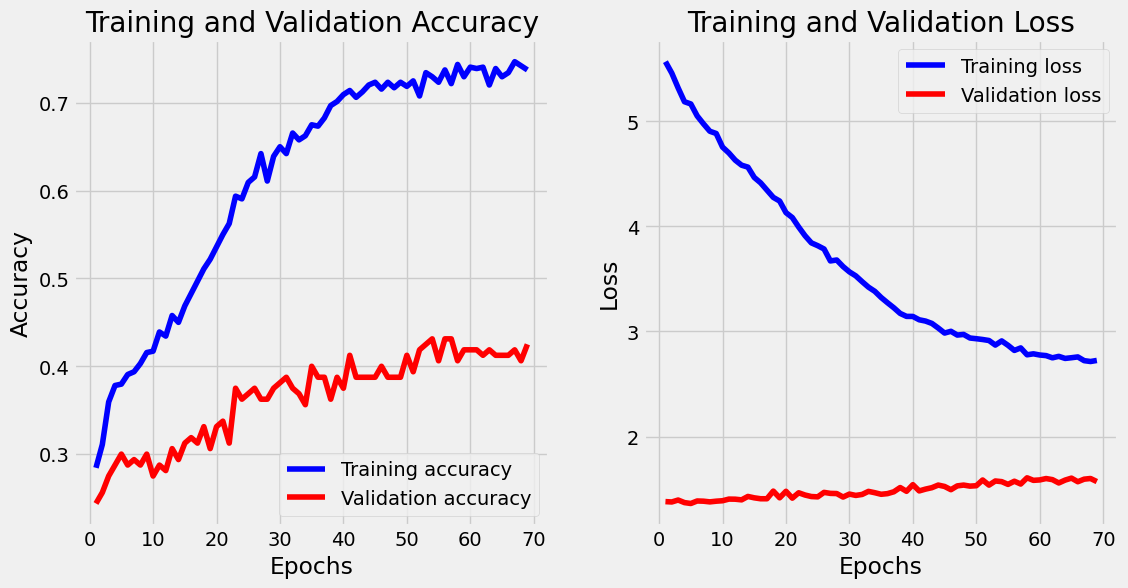

In [74]:
# # Predict on test data
import matplotlib.pyplot as plt

# Get the actual number of epochs model was trained for
n_epochs = len(training_accuracy)

epochs = range(1, n_epochs+1)

# Plot training and validation accuracy
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(epochs, training_accuracy, 'b-', label='Training accuracy')
plt.plot(epochs, validation_accuracy, 'r-', label='Validation accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Plot training and validation loss
plt.subplot(1, 2, 2)
plt.plot(epochs, training_loss, 'b-', label='Training loss')
plt.plot(epochs, validation_loss, 'r-', label='Validation loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.show()


In [75]:
# Calculate class weights
total_samples = len(y_train)
class_weights = {0: total_samples / np.sum(y_train[:, 0]),
                 1: total_samples / np.sum(y_train[:, 1]),
                 2: total_samples / np.sum(y_train[:, 2]),
                 3: total_samples / np.sum(y_train[:, 3])} # Updated for 4 classes

# Train the model with class weights
history = emotion_model.fit(X_train, y_train, batch_size=32, epochs=100, validation_split=0.1, class_weight=class_weights,verbose=0)

# Evaluate the model on test data
loss, accuracy = emotion_model.evaluate(X_test, y_test)
losstr, accuracytr = emotion_model.evaluate(X_train, y_train)

print(f"Test accuracy: {accuracy*100:.2f}%")
print(f"Train accuracy: {accuracytr*100:.2f}%")

# Save the trained model
emotion_model.save("/content/drive/MyDrive/Pet_emothion_Recognition-main/Pet_facial_emotion_model.h5")


7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.4200 - loss: 1.5383
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7450 - loss: 0.7065


Test accuracy: 42.00%
Train accuracy: 74.50%



CLASSIFICATION REPORT
              precision    recall  f1-score   support

       Angry       0.43      0.68      0.53        44
       Happy       0.42      0.15      0.23        52
         Sad       0.54      0.55      0.54        55
       Other       0.29      0.33      0.31        49

    accuracy                           0.42       200
   macro avg       0.42      0.43      0.40       200
weighted avg       0.42      0.42      0.40       200



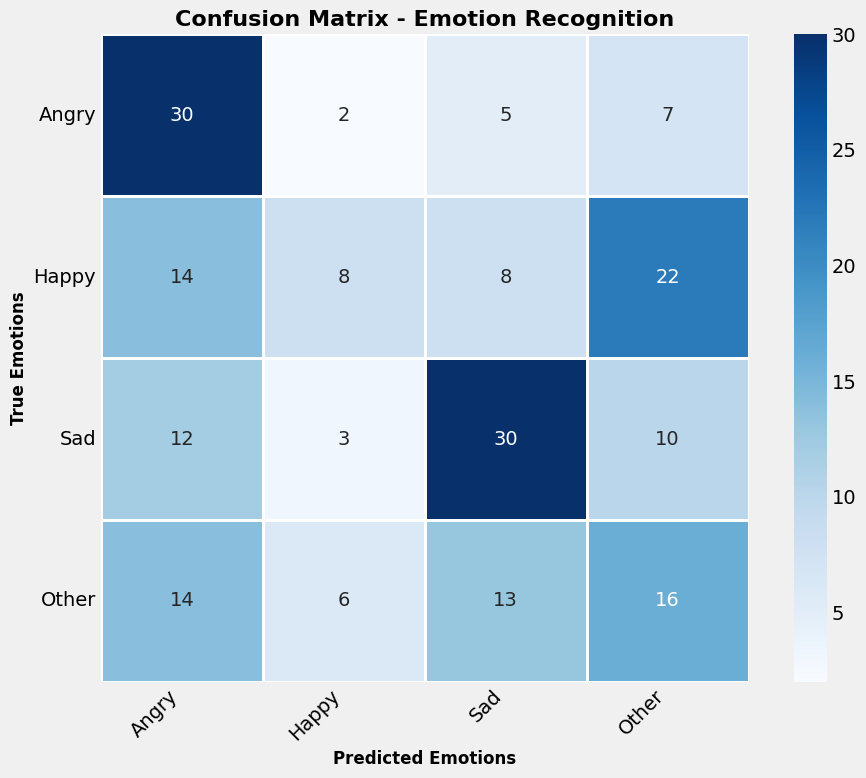

In [86]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

# Predict on test set
y_pred = emotion_model.predict(X_test, verbose=0)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true_classes = np.argmax(y_test, axis=1)

# Define emotion labels (adjust based on your actual emotion classes)
# Assuming order: [Angry, Happy, Sad, Neutral] or whatever your 4 emotions are
emotion_labels = ['Angry', 'Happy', 'Sad', 'Other']  # Update these based on your actual classes

# Calculate confusion matrix
cm = confusion_matrix(y_true_classes, y_pred_classes)

# Print classification report
print("\n" + "=" * 60)
print("CLASSIFICATION REPORT")
print("=" * 60)
print(classification_report(y_true_classes, y_pred_classes, target_names=emotion_labels))

# Plot confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=emotion_labels,
            yticklabels=emotion_labels,
            cbar=True,
            square=True,
            linewidths=1,
            linecolor='white')

plt.title('Confusion Matrix - Emotion Recognition', fontsize=16, fontweight='bold')
plt.xlabel('Predicted Emotions', fontsize=12, fontweight='bold')
plt.ylabel('True Emotions', fontsize=12, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()




### Test on Unseen Dataset

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 516ms/step
Predicted Emotion: angry
Confidence [happy, sad, angry]: [0.02263528 0.02754348 0.92597365 0.02384761]


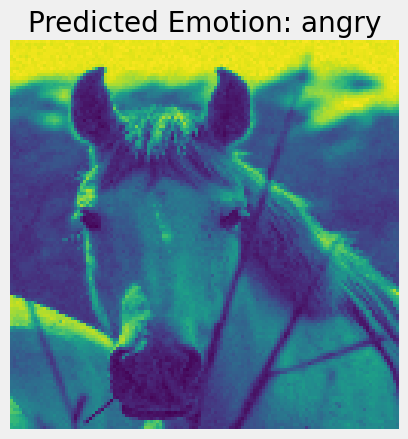

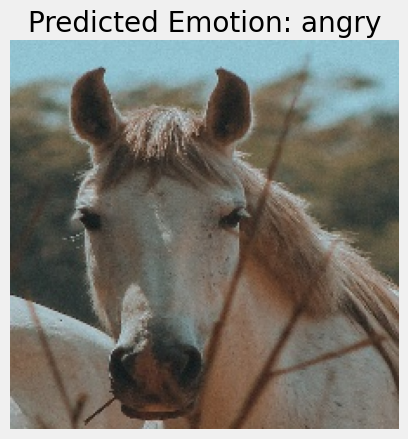

In [76]:
# Load the saved model
loaded_model = load_model("/content/drive/MyDrive/Pet_emothion_Recognition-main/Pet_facial_emotion_model.h5")
# Load a custom test image
custom_test_image_path = "/content/drive/MyDrive/Pet_emothion_Recognition-main/pets_facial_expression_dataset/Angry/78.jpg"

custom_test_image = cv2.imread(custom_test_image_path)
# custom_test_image = cv2.cvtColor(custom_test_image, cv2.COLOR_BGR2GRAY)
custom_test_image = cv2.resize(custom_test_image, (128, 128))
custom_test_image = custom_test_image.astype('float32') / 255.0

# Reshape the image to match the model input shape
custom_test_image = np.expand_dims(custom_test_image, axis=0)
custom_test_image = np.expand_dims(custom_test_image, axis=-1)

# Make predictions on the custom test image
prediction = loaded_model.predict(custom_test_image)
prediction_prob = prediction[0]

emotion_label = np.argmax(prediction[0])

# Map the predicted label to emotion class
emotion_classes = {0: 'happy', 1: 'sad', 2: 'angry',3:"clam"}
predicted_emotion = emotion_classes[emotion_label]

# Print the custom test image and its predicted label
print(f"Predicted Emotion: {predicted_emotion}")
print(f"Confidence [happy, sad, angry]: {prediction_prob}")

import matplotlib.pyplot as plt

#Display the custom test image using matplotlib
plt.imshow(custom_test_image[0, :, :, 0])
plt.title(f"Predicted Emotion: {predicted_emotion}")
plt.axis('off')  # Hide axes
plt.show()

from PIL import Image
# Display the original custom test image using PIL
img_pil = Image.open(custom_test_image_path)
plt.imshow(np.array(img_pil))
plt.title(f"Predicted Emotion: {predicted_emotion}")
plt.axis('off')  # Hide axes
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 530ms/step
Predicted Emotion: sad
Confidence [happy, sad, angry]: [0.29631907 0.35144752 0.11938366 0.23284979]


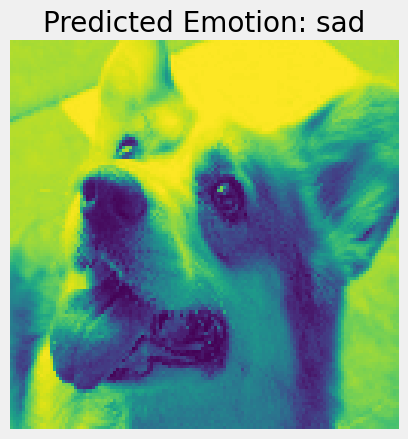

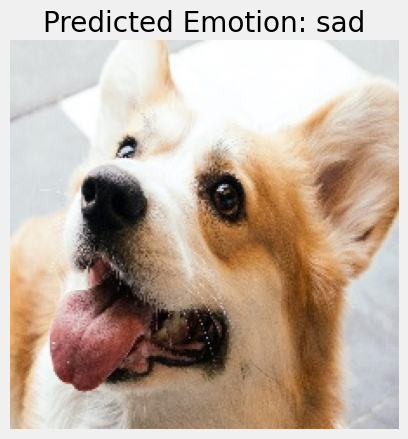

In [80]:
from keras.models import load_model
# Load the saved model
loaded_model = load_model("/content/drive/MyDrive/Pet_emothion_Recognition-main/Pet_facial_emotion_model.h5")

# Function to load and preprocess images
def load_images_from_folder(folder):
    images = []
    for filename in os.listdir(folder):
        img = cv2.imread(os.path.join(folder, filename))
        if img is not None:
            # img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
            img = cv2.resize(img, (128, 128))  # Resize to a fixed size for the model
            images.append(img)
    return images


# Load a custom test image
custom_test_image_path = "/content/drive/MyDrive/Pet_emothion_Recognition-main/pets_facial_expression_dataset/happy/111.jpg"

custom_test_image = cv2.imread(custom_test_image_path)
# custom_test_image = cv2.cvtColor(custom_test_image, cv2.COLOR_BGR2GRAY)
custom_test_image = cv2.resize(custom_test_image, (128, 128))
custom_test_image = custom_test_image.astype('float32') / 255.0

# Reshape the image to match the model input shape
custom_test_image = np.expand_dims(custom_test_image, axis=0)
custom_test_image = np.expand_dims(custom_test_image, axis=-1)

# Make predictions on the custom test image
prediction = loaded_model.predict(custom_test_image)
prediction_prob = prediction[0]

emotion_label = np.argmax(prediction[0])

# Map the predicted label to emotion class
emotion_classes = {0: 'happy', 1: 'sad', 2: 'angry'}
predicted_emotion = emotion_classes[emotion_label]

# Print the custom test image and its predicted label
print(f"Predicted Emotion: {predicted_emotion}")
print(f"Confidence [happy, sad, angry]: {prediction_prob}")

import matplotlib.pyplot as plt

#Display the custom test image using matplotlib
plt.imshow(custom_test_image[0, :, :, 0])
plt.title(f"Predicted Emotion: {predicted_emotion}")
plt.axis('off')  # Hide axes
plt.show()

from PIL import Image
# Display the original custom test image using PIL
img_pil = Image.open(custom_test_image_path)
plt.imshow(np.array(img_pil))
plt.title(f"Predicted Emotion: {predicted_emotion}")
plt.axis('off')  # Hide axes
plt.show()